# EDA
## Tải tất cả thư viện cần thiết và xử lý dataframe

In [187]:
import pandas as pd
import matplotlib.pyplot as pit

# Đọc file
df = pd.read_csv('../api/used_cars.csv')
df


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


## Xử lý các ký tự cần thiết

In [188]:
from sklearn.preprocessing import LabelEncoder
import re

# Xử lý giá tiền của xe từ chuỗi thành số

df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

# Xử lý số dặm xe đã đi

df['milage'] = (
    df['milage']
    .str.replace(',', '', regex=False)
    .str.replace('mi.', '', regex=False)
    .astype(int)
)

df['milage']

# Thêm cột "age" để biểu diễn số tuổi của chiếc xe

df['age'] = 2026 - df['model_year']

# Chuyển đổi nhiên liệu thành dạng dữ liệu để phân tích (Label endcoding)
le = LabelEncoder()
df['fuel_type'] = le.fit_transform(df['fuel_type'])

# Thêm cột horsepower để biểu diễn số mã lực dựa trên cột "engine" của chiếc xe

df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)').astype(float)

# Xóa cột not supported trong dữ liệu

fuel_counts = df['fuel_type'].value_counts()
fuel_counts = fuel_counts.drop(5)

fuel_counts


fuel_type
2    3309
3     194
7     170
1     139
0     116
6      45
4      34
Name: count, dtype: int64

## Xử lý các giá trị null

In [189]:
# Số lượng giá trị null

df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
age               0
horsepower       78
dtype: int64

In [190]:
# Xóa các hàng có các giá trị là null hoặc không có giá trị

df = df.dropna(axis=0)

In [191]:
# Kiểm tra lại các giá trị null hoặc không có giá trị

df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
age             0
horsepower      0
dtype: int64

In [192]:
# Hiển thị các giá trị cơ bản trong dataframe
df.describe()

,model_year,milage,fuel_type,price,age,horsepower
count,3359.000000,3359.000000,3359.000000,3.359000e+03,3359.000000,3359.000000
mean,2014.997916,69969.996725,2.165228,4.184295e+04,11.002084,307.731468
std,5.871489,53159.627706,1.103530,8.147854e+04,5.871489,144.486065
min,1996.000000,100.000000,0.000000,2.000000e+03,2.000000,1.200000
25%,2011.000000,27516.000000,2.000000,1.599500e+04,6.000000,228.000000
50%,2016.000000,60000.000000,2.000000,2.900000e+04,10.000000,302.000000
75%,2020.000000,100000.000000,2.000000,4.794750e+04,15.000000,395.000000
max,2024.000000,405000.000000,7.000000,2.954083e+06,30.000000,1020.000000


In [193]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,age,horsepower
0,Ford,Utility Police Interceptor Base,2013,51000,1,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,13,300.0
1,Hyundai,Palisade SEL,2021,34742,2,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,5,3.8
3,INFINITI,Q50 Hybrid Sport,2015,88900,3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,11,354.0
6,Audi,S3 2.0T Premium Plus,2017,84000,2,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000,9,292.0
7,BMW,740 iL,2001,242000,2,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,7300,25,282.0


In [194]:
# Hiển thị các giá trị cơ bản trong dataframe
df.describe()

,model_year,milage,fuel_type,price,age,horsepower
count,3359.000000,3359.000000,3359.000000,3.359000e+03,3359.000000,3359.000000
mean,2014.997916,69969.996725,2.165228,4.184295e+04,11.002084,307.731468
std,5.871489,53159.627706,1.103530,8.147854e+04,5.871489,144.486065
min,1996.000000,100.000000,0.000000,2.000000e+03,2.000000,1.200000
25%,2011.000000,27516.000000,2.000000,1.599500e+04,6.000000,228.000000
50%,2016.000000,60000.000000,2.000000,2.900000e+04,10.000000,302.000000
75%,2020.000000,100000.000000,2.000000,4.794750e+04,15.000000,395.000000
max,2024.000000,405000.000000,7.000000,2.954083e+06,30.000000,1020.000000


# Vẽ các biểu đồ cần thiết

## Biểu đồ đường biểu diễn tổng số xe của hãng đó trong các năm

Index(['Ford', 'BMW', 'Mercedes-Benz', 'Chevrolet', 'Toyota'], dtype='str', name='brand')


Text(0.5, 1.0, 'Biểu đồ số lượng xe các năm của các hãng top đầu')

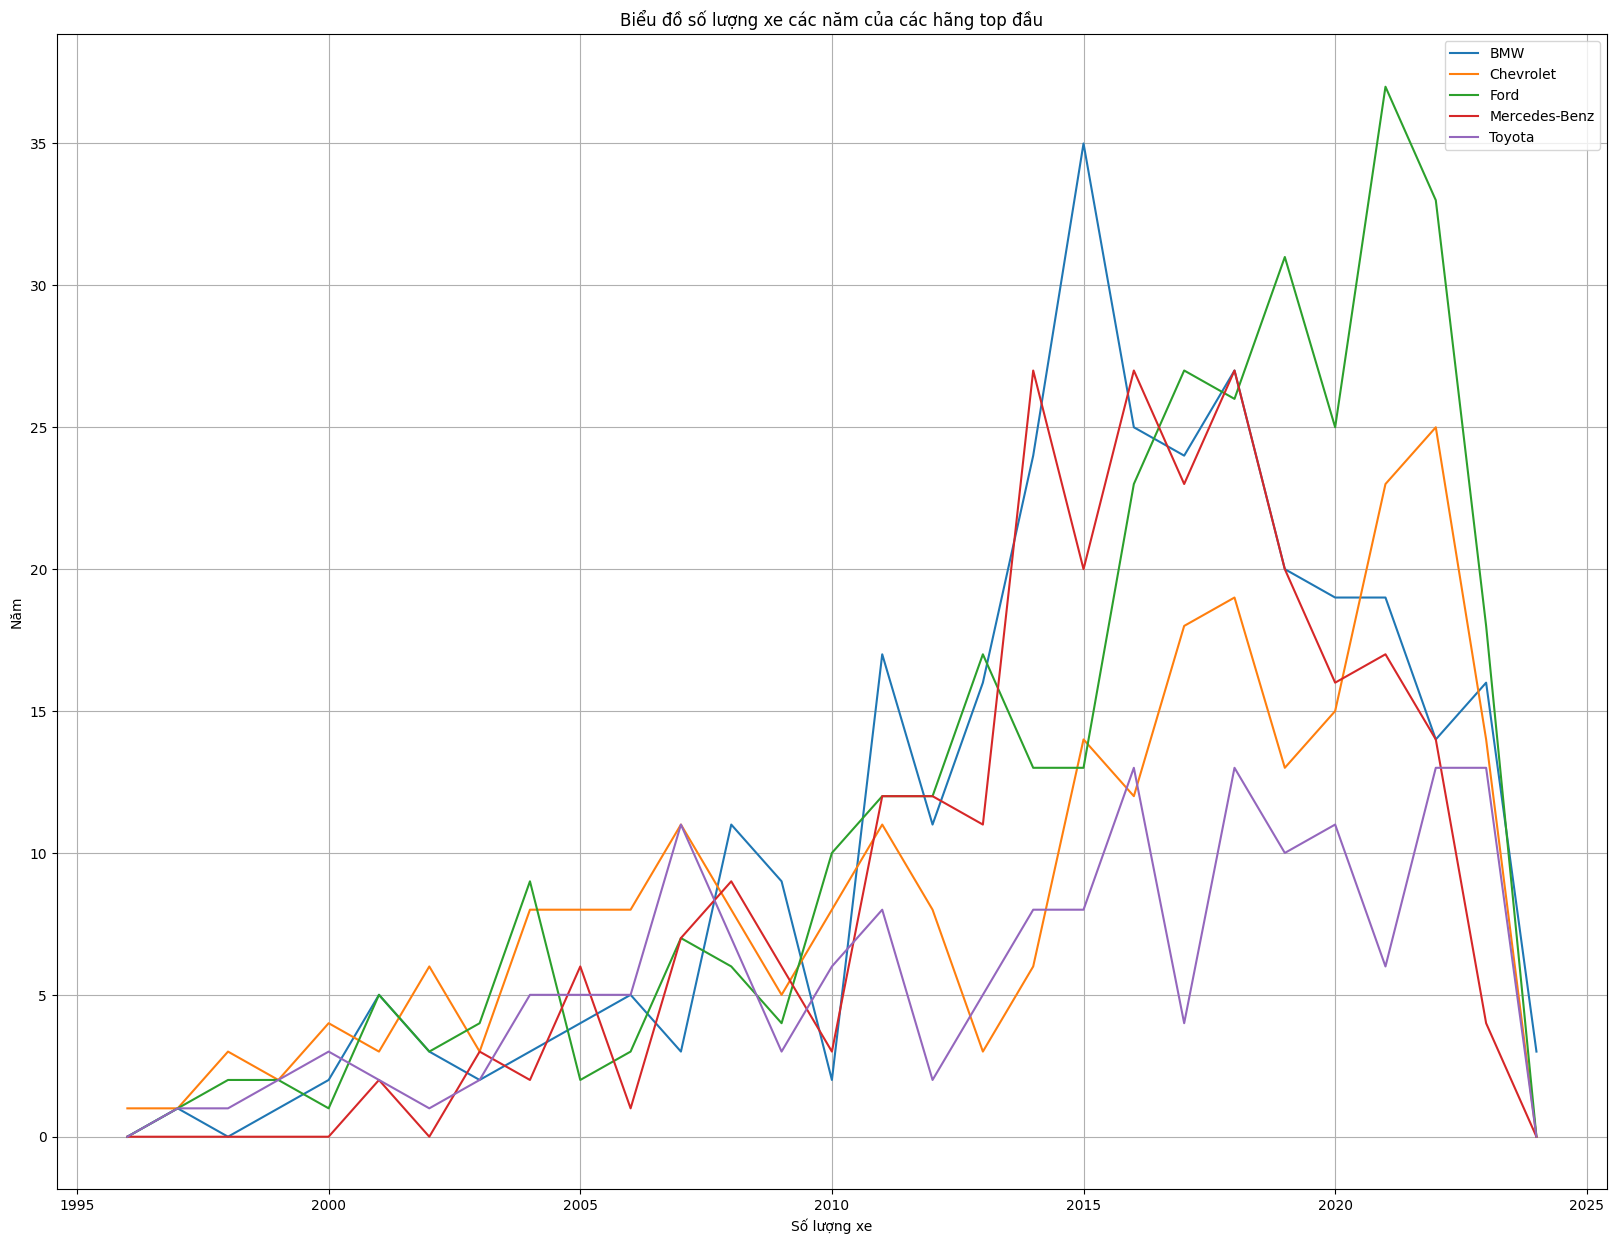

In [195]:
# Biều đồ đường: Dùng để biểu diễn tổng số xe của hãng đó trong các năm

top_brand = df['brand'].value_counts().head().index

print(top_brand)
df_top_brand = df[df['brand'].isin(top_brand)]
pivot_df = df_top_brand.pivot_table(index='model_year', columns='brand', values='model', aggfunc='count', fill_value=0)

pit.figure(figsize=(20, 15))
for brand in pivot_df.columns:
    pit.plot(pivot_df.index, pivot_df[brand], label=brand)

pit.xlabel('Số lượng xe')
pit.ylabel('Năm')
pit.legend()
pit.grid()
pit.title('Biểu đồ số lượng xe các năm của các hãng top đầu')

## Biểu đồ cột biểu diễn top 10 hãng xe có tống số lượng xe lớn nhất

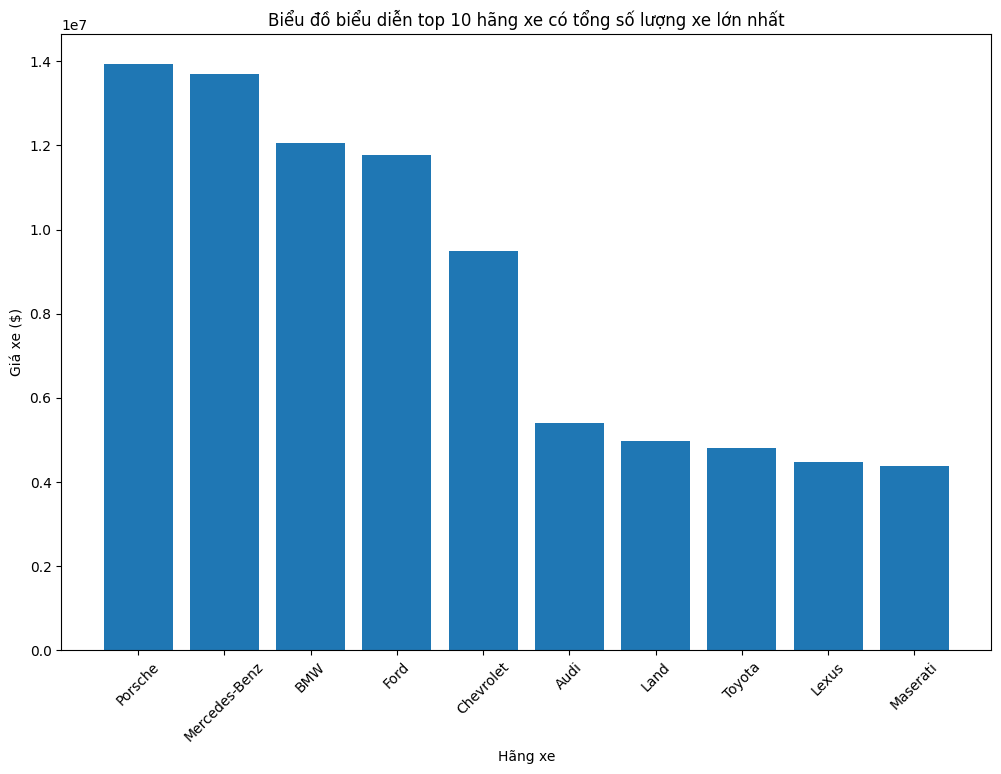

In [196]:
# Biểu đồ cột: Dùng để biểu diễn top 10 hãng xe có tổng số lượng xe lớn nhất

df_sum_brand = df[['brand', 'price']].groupby('brand').sum()
df_sum_brand = df_sum_brand.sort_values(by='price', ascending=False).head(10)
df_sum_brand

pit.figure(figsize=(12, 8))
pit.bar(x=df_sum_brand.index, height=df_sum_brand['price'])
pit.xticks(rotation=45)
pit.title('Biểu đồ biểu diễn top 10 hãng xe có tổng số lượng xe lớn nhất')
pit.xlabel('Hãng xe')
pit.ylabel('Giá xe ($)')
pit.show()


## Biểu đồ box plot biểu diễn giá trị ngoại lai

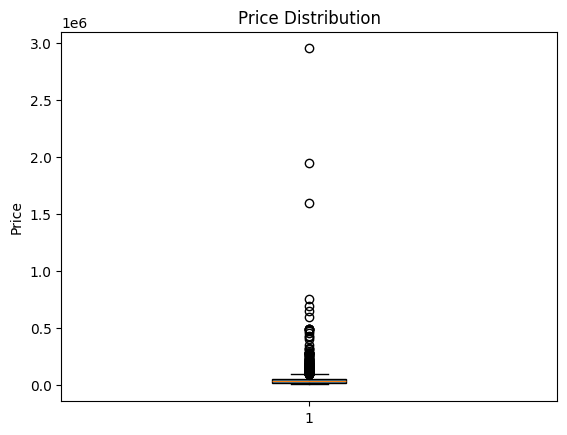

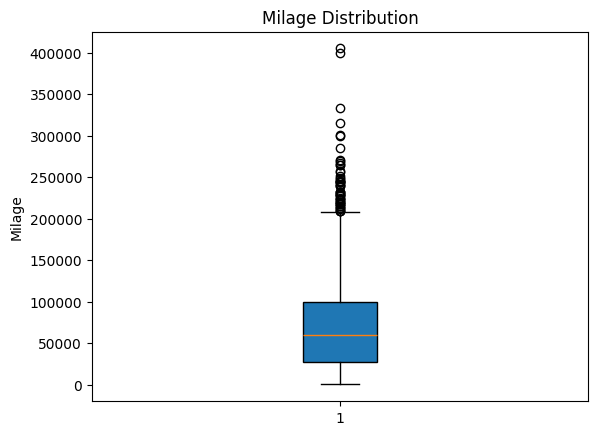

In [197]:
# Biều đồ biểu thị giá trị ngoại lai (Box plot)

pit.boxplot(df['price'], patch_artist=True)
pit.title("Price Distribution")
pit.ylabel("Price")
pit.show()

pit.boxplot(df['milage'], patch_artist=True)
pit.title("Milage Distribution")
pit.ylabel("Milage")
pit.show()


## Biểu đồ hồi quy tuyến tính đa biến dùng để biểu diễn mối quan hệ giữa các dữ liệu và giá xe

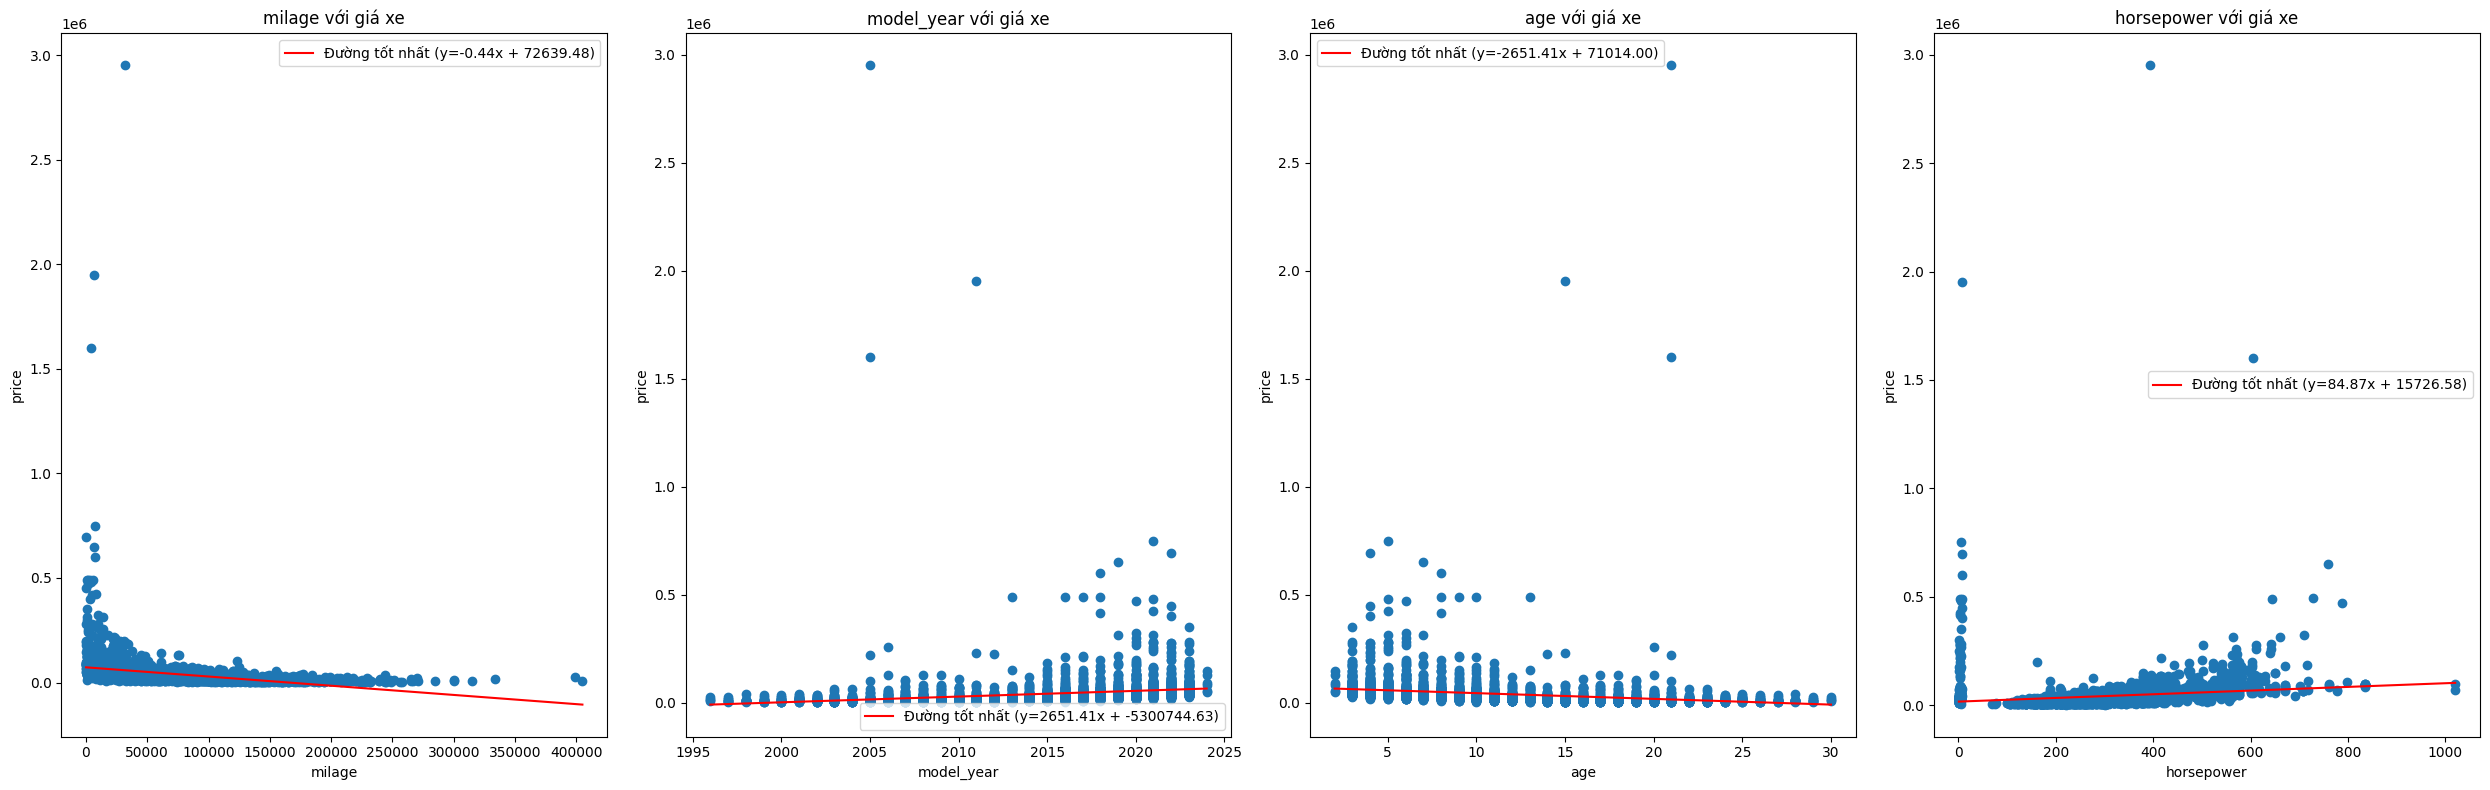

In [198]:
import numpy as np

# Biểu đồ hồi quy tuyến tính đa biến biểu diễn mối quan hệ giữa số km đi, số năm sản suất, màu và giá xe

features = ['milage', 'model_year', 'age', 'horsepower']
target = 'price'

pit.figure(figsize=(25, 8))
for i, col in enumerate(features):

    # Lấy dữ liệu để vẽ biểu đồ
    x = df[col]
    y = df[target]

    # Vẽ biểu đồ scatter plot
    pit.subplot(1, 4, i + 1)
    a, b = np.polyfit(x, y, 1)
    pit.scatter(df[col], df[target])

    # Dùng để sắp xếp thứ tự bé đến lớn cho các dữ liệu nếu không khi vẽ đường hồi quy sẽ thành zig zag
    sort_idx = np.argsort(x)
    pit.plot(x.iloc[sort_idx], (a * x + b).iloc[sort_idx], color='red', label=f'Đường tốt nhất (y={a:.2f}x + {b:.2f})')

    # Các chi tiết phụ
    pit.xlabel(col)
    pit.ylabel(target)
    pit.title(f'{col} với giá xe')
    pit.legend()

pit.tight_layout()
pit.show()

## Biểu đồ quạt (pie chart) biểu diễn phần trăm các dữ liệu

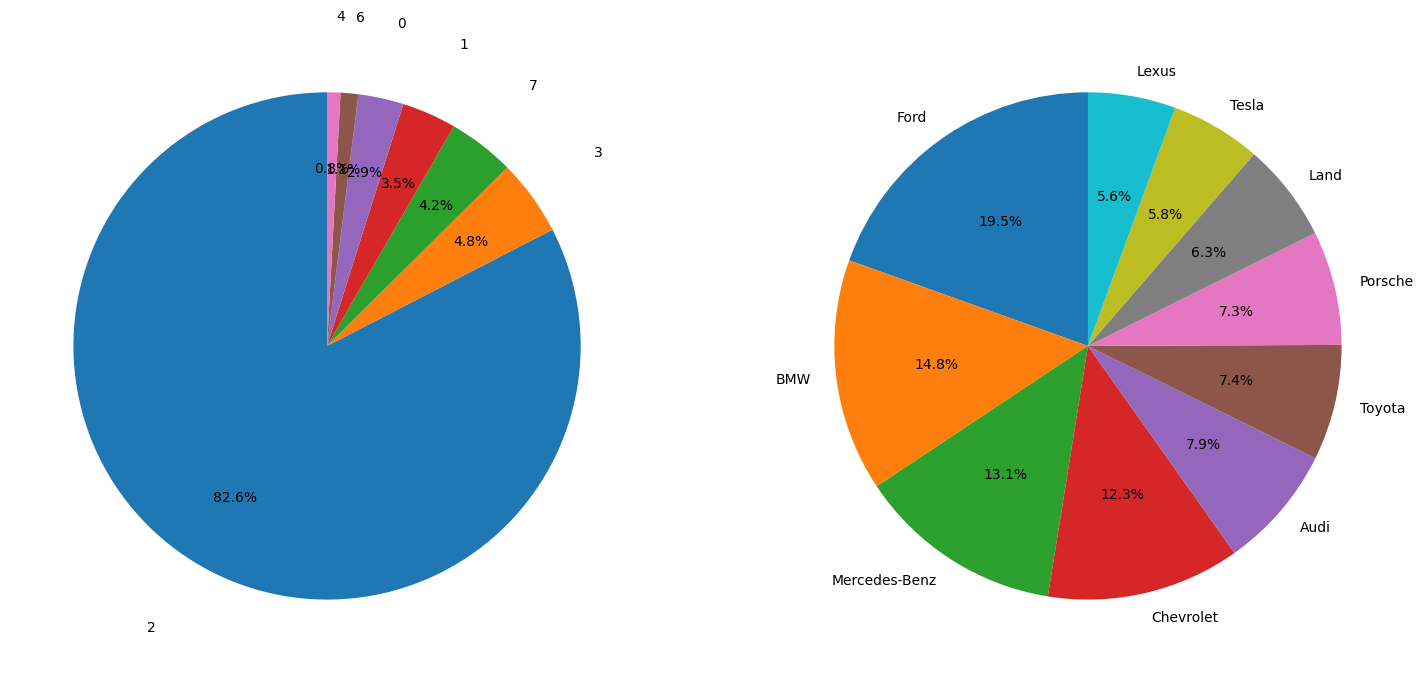

In [199]:
# Biểu đồ tròn biểu diễn phần trăm các dữ liệu

df_10years = df[df['model_year'] >= 2026 -10]
top_10_brand = df_10years['brand'].value_counts().head(10)

pit.figure(figsize=(18, 10))

# 1. Biều đồ tròn biểu diễn phần trăm các nhiên liệu của các hãng xe

pit.subplot(1, 2, 1)
pit.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%', startangle=90, labeldistance=1.3, pctdistance=0.7)

# 2. Biều đồ tròn biểu diễn phần trăm tổng xe của top 10 hãng xe trong 10 năm gần nhất

pit.subplot(1, 2, 2)
pit.pie(top_10_brand, labels=top_10_brand.index, autopct='%1.1f%%', startangle=90)

pit.show()

# Biểu diễn mức độ tương quan của các dữ liệu với nhau

In [200]:
# Biếu diễn mức độ tương quan (Correlation) của các dữ liệu với nhau (milage, fuel type, age và horsepower với price)

correlation_milage = df['milage'].corr(df['price'])
correlation_age = df['age'].corr(df['price'])
correlation_hp = df['horsepower'].corr(df['price'])

print(f'Hệ số tương quan giữa số km đi và giá xe: {correlation_milage}')
print(f'Hệ số tương quan giữa số km đi và giá xe: {correlation_age}')
print(f'Hệ số tương quan giữa số km đi và giá xe: {correlation_hp}')
df

Hệ số tương quan giữa số km đi và giá xe: -0.28716306294351246
Hệ số tương quan giữa số km đi và giá xe: -0.1910654185811666
Hệ số tương quan giữa số km đi và giá xe: 0.15049558204101787


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,age,horsepower
0,Ford,Utility Police Interceptor Base,2013,51000,1,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,13,300.0
1,Hyundai,Palisade SEL,2021,34742,2,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,5,3.8
3,INFINITI,Q50 Hybrid Sport,2015,88900,3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,11,354.0
6,Audi,S3 2.0T Premium Plus,2017,84000,2,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000,9,292.0
7,BMW,740 iL,2001,242000,2,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,7300,25,282.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4003,Mercedes-Benz,E-Class E 300 4MATIC,2018,53705,2,241.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,Yes,25900,8,241.0
4004,Bentley,Continental GT Speed,2023,714,2,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,349950,3,6.0
4005,Audi,S4 3.0T Premium Plus,2022,10900,2,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,53900,4,349.0
4007,Ford,F-150 Raptor,2020,33000,2,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,62999,6,450.0


# Huấn luyện mô hình

In [202]:
from sklearn.linear_model import LinearRegression

# Huấn luyện mô hình


le = LabelEncoder()
df['brand'] = le.fit_transform(df['brand'])
model = LinearRegression()

X = df[[
    'brand',
    'model_year',
    'milage',
    'fuel_type',
    'age',
    'horsepower'
]]

y = df['price']

model.fit(X, y)

# Dự đoán giá xe với các giá trị người dùng nhập vào
new_car = pd.DataFrame({
    "milage": [50000],
    'age': [8],
    'horsepower': [200.0]
})

prediction = model.predict(new_car)

print(f"Dự đoán giá xe: {prediction}")
print(f"Hệ số gốc: {model.coef_}")
print(f"Hệ số chặn: {model.intercept_}")

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- brand
- fuel_type
- model_year


# Chia tập dữ liệu để train và test và đánh giá kết quả dự đoán bằng các chỉ số

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Huấn luyện và đánh giá mô hình

X = df[[
    'milage',
    'age',
    'horsepower'
]]
y = df['price']

# Chia tập dữ liệu thành 80% train và 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Đánh giá kết quả dự đoán bằng chỉ số MSE và r^2d

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Sai số (MSE): {mse}')
print(f'Độ khớp (R2 Score): {r2}')
print(f'So lệch giá trị: {mae}')

Sai số (MSE): 14682051650.390038
Độ khớp (R2 Score): 0.044229258745028366
So lệch giá trị: 23879.46201135764


# Biểu đồ biễu diễn độ chính xác của mô hình (Dự đoán và thực tế)

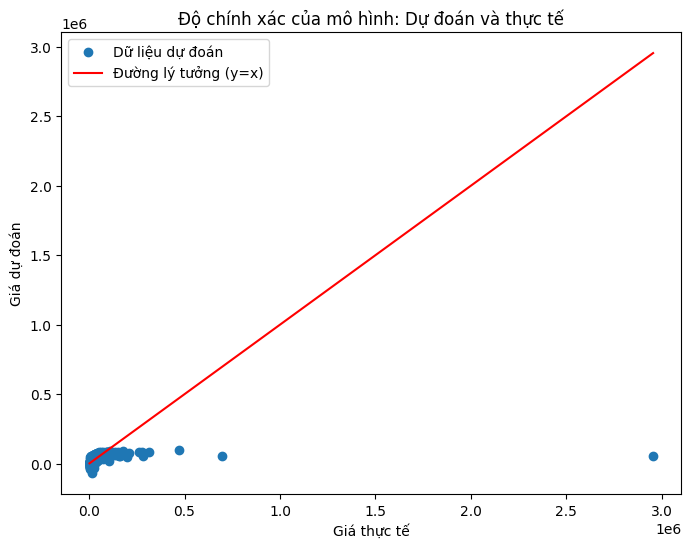

In [ ]:
pit.figure(figsize=(8, 6))

pit.scatter(y_test, y_pred, label='Dữ liệu dự đoán')

line_coords = [y.min(), y.max()]
pit.plot(line_coords, line_coords, color='red', label='Đường lý tưởng (y=x)')

pit.xlabel('Giá thực tế')
pit.ylabel('Giá dự đoán')
pit.title('Độ chính xác của mô hình: Dự đoán và thực tế')
pit.legend()
pit.show()